# Which variables should you control for?

My analytics degree gave me a working answer to this: **all of them.** Throw
every covariate you have into the regression, watch adjusted R² go up, and
report the coefficient. More controls, more rigour.

That heuristic is wrong, and it is wrong in two separate ways. This notebook
demonstrates both on simulated data where the true answer is known in advance,
so there is no arguing about what the right number was.

Three variables, three roles, three completely different instructions:

| Role | What it is | Adjust for it? |
|---|---|---|
| **Confounder** | a common cause of treatment and outcome | **Yes** — otherwise your estimate is biased |
| **Mediator** | sits on the causal path from treatment to outcome | **Depends** — it changes *which question you answered* |
| **Collider** | a common *effect* of two variables on the path | **No** — adjusting creates bias that was not there |

The last row is the one that should be alarming. Adding a control variable can
take an estimate that was correct and make it wrong.

Crucially, **you cannot tell these apart from the data.** All three produce
correlations. The difference is in the causal structure, which has to come from
you — from domain knowledge, written down as a graph, before you fit anything.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import statsmodels.api as sm

from causalblocks import (
    CausalDAG, simulate, true_total_effect, true_direct_effect,
    confounded, mediated, m_bias, set_theme,
)

set_theme()
pd.set_option("display.precision", 3)

N, SEED = 40_000, 20260807

def ols(df, treatment, outcome, controls=()):
    """Coefficient on `treatment`, optionally holding `controls` fixed."""
    design = sm.add_constant(df[[treatment, *controls]])
    return sm.OLS(df[outcome], design).fit().params[treatment]

## The setup

Every graph below is a **linear structural causal model**: each variable is a
weighted sum of its parents plus independent noise. That is a strong assumption
and a deliberate one — because the model is linear, the true causal effect has a
closed form, so we can check whether an estimator recovers the number we
planted.

The closed form is **Wright's path-tracing rule**: the total effect is the sum,
over every directed path from treatment to outcome, of the product of that
path's edge weights. `true_total_effect()` implements it. This is what turns a
simulation into a test rather than a demonstration.

---
## Case 1 — The confounder: adjusting is *required*

`Z` causes both the treatment and the outcome. This is the case everyone is
taught, and it is why "control for things" became the default instinct.

The true effect of `X` on `Y` is **1.5**.

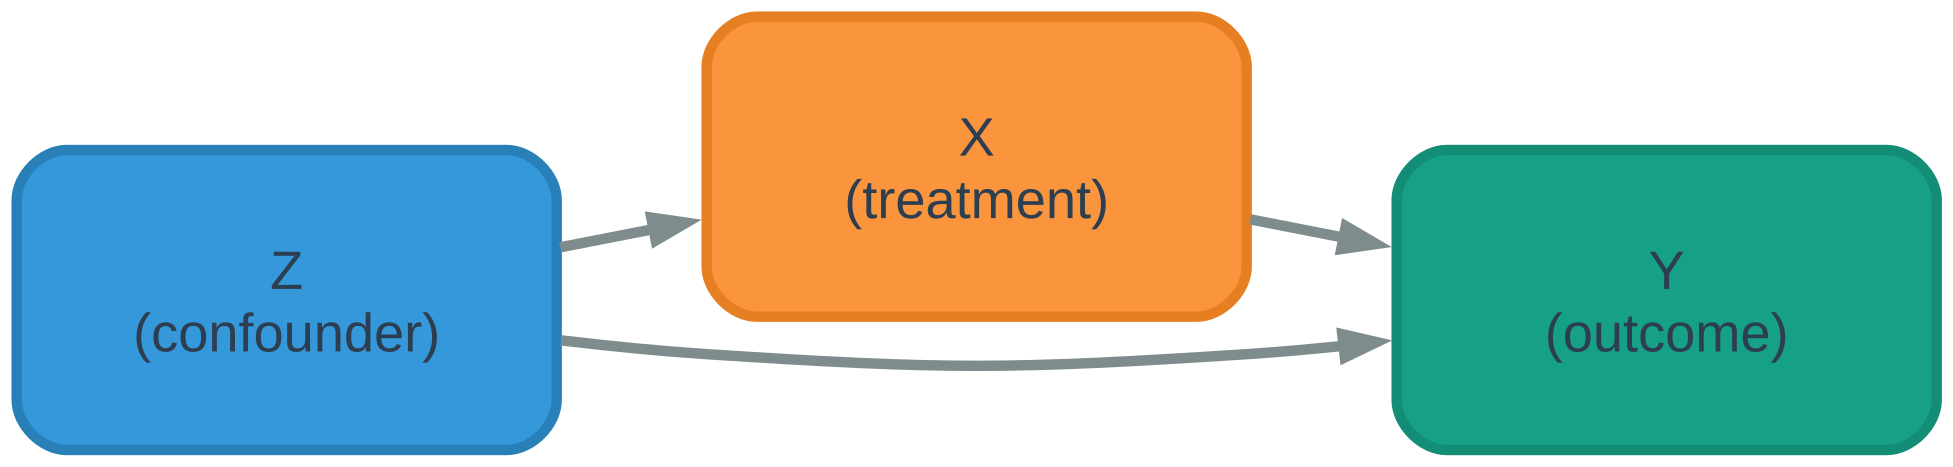

In [2]:
dag = confounded()
dag.draw("X", "Y")

Nothing in that diagram was hand-coloured. `Z` is drawn as a
confounder because it *is* one — the label is computed from the graph structure
given the treatment and outcome. This matters more than it sounds like it
should; there is a case at the end of this notebook where I got it wrong by
hand.

`explain()` reads the graph back in plain language:

In [3]:
print(dag.explain("X", "Y"))

Treatment: X
Outcome:   Y

CONFOUNDER: Z
    adjust for it -- it is a common cause and leaves an open backdoor path

WHAT A BACKDOOR ADJUSTMENT GIVES YOU:
    Adjusting for {Z} -> TOTAL effect. No mediators, so total and direct coincide.


In [4]:
df = simulate(dag, n=N, seed=SEED)
truth = true_total_effect(dag, "X", "Y")

print(f"True effect of X on Y      : {truth:.3f}")
print(f"Naive  (Y ~ X)             : {ols(df, 'X', 'Y'):.3f}   <- wrong")
print(f"Adjusted (Y ~ X + Z)       : {ols(df, 'X', 'Y', ['Z']):.3f}   <- correct")

True effect of X on Y      : 1.500
Naive  (Y ~ X)             : 2.504   <- wrong
Adjusted (Y ~ X + Z)       : 1.505   <- correct


The naive estimate is inflated by roughly 1.0. `Z` raises both
`X` and `Y`, so some of `Z`'s influence on `Y` gets misattributed to `X`.
Adjusting for `Z` removes it and recovers 1.5.

So far the heuristic holds: more controls, better answer. Now watch it break.

---
## Case 2 — The mediator: adjusting changes the question

`M` sits *on* the causal path. `X` affects `Y` directly, and also by moving `M`,
which moves `Y`.

- Direct effect: **1.0**
- Indirect effect through `M`: 0.5 × 2.0 = **1.0**
- Total effect: **2.0**

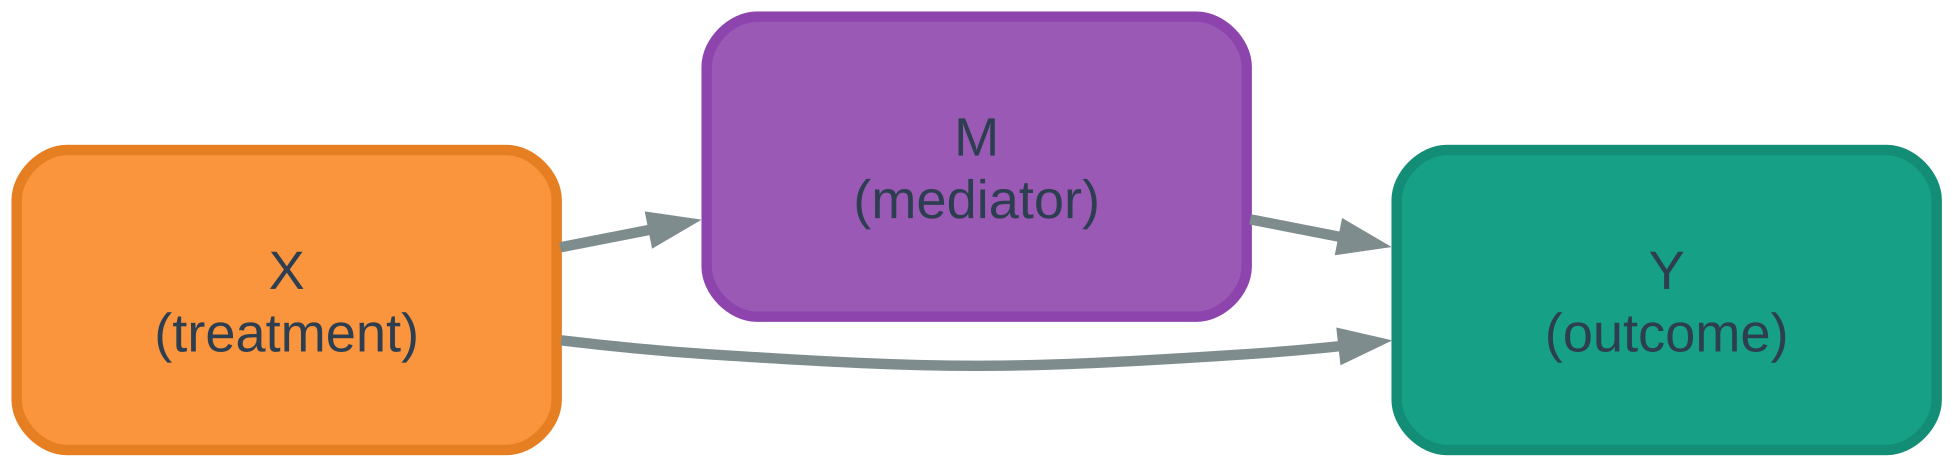

In [5]:
dag = mediated()
dag.draw("X", "Y")

In [6]:
df = simulate(dag, n=N, seed=SEED)

print(f"True TOTAL effect          : {true_total_effect(dag, 'X', 'Y'):.3f}")
print(f"True DIRECT effect         : {true_direct_effect(dag, 'X', 'Y'):.3f}")
print()
print(f"Naive  (Y ~ X)             : {ols(df, 'X', 'Y'):.3f}   <- the TOTAL effect")
print(f"Adjusted (Y ~ X + M)       : {ols(df, 'X', 'Y', ['M']):.3f}   <- the DIRECT effect")

True TOTAL effect          : 2.000
True DIRECT effect         : 1.000

Naive  (Y ~ X)             : 1.993   <- the TOTAL effect
Adjusted (Y ~ X + M)       : 1.000   <- the DIRECT effect


**Neither number is wrong.** They answer different questions:

- *"If I change `X`, what happens to `Y`?"* → the total effect, **2.0**. This is
  almost always the decision-relevant one, because when you intervene on `X` in
  the real world, `M` moves too.
- *"If I change `X` while somehow holding `M` fixed, what happens to `Y`?"* →
  the direct effect, **1.0**.

The failure mode here is not bias. It is reporting one number while your reader
assumes the other, and nothing in the regression output tells either of you
which happened. This is called **overcontrol bias** or **mediator bias**, and it
is invisible: adjusted R² goes *up* when you add the mediator, so every
model-selection habit I was taught pushes toward the wrong specification.

`explain()` says it outright:

In [7]:
print(dag.explain("X", "Y"))

Treatment: X
Outcome:   Y

MEDIATOR: M
    adjusting for it gives the DIRECT effect, not the total effect

WHAT A BACKDOOR ADJUSTMENT GIVES YOU:
    Adjusting for {nothing} -> TOTAL effect (through every pathway).
    Adding the mediator(s) {M} -> DIRECT effect only.
    These answer different questions. Say which one you report.


---
## Case 3 — The collider: adjusting *creates* bias

This is the one that should change how you work.

The graph is **M-bias**, named for the shape the arrows make. Two hidden causes,
`U1` and `U2`. `U1` affects `X` and `M`; `U2` affects `M` and `Y`. `M` is a
common *effect* of two things — arrows collide into it.

And critically: **there is no arrow from `X` to `Y` at all.** The true effect is
exactly **zero**, by construction.

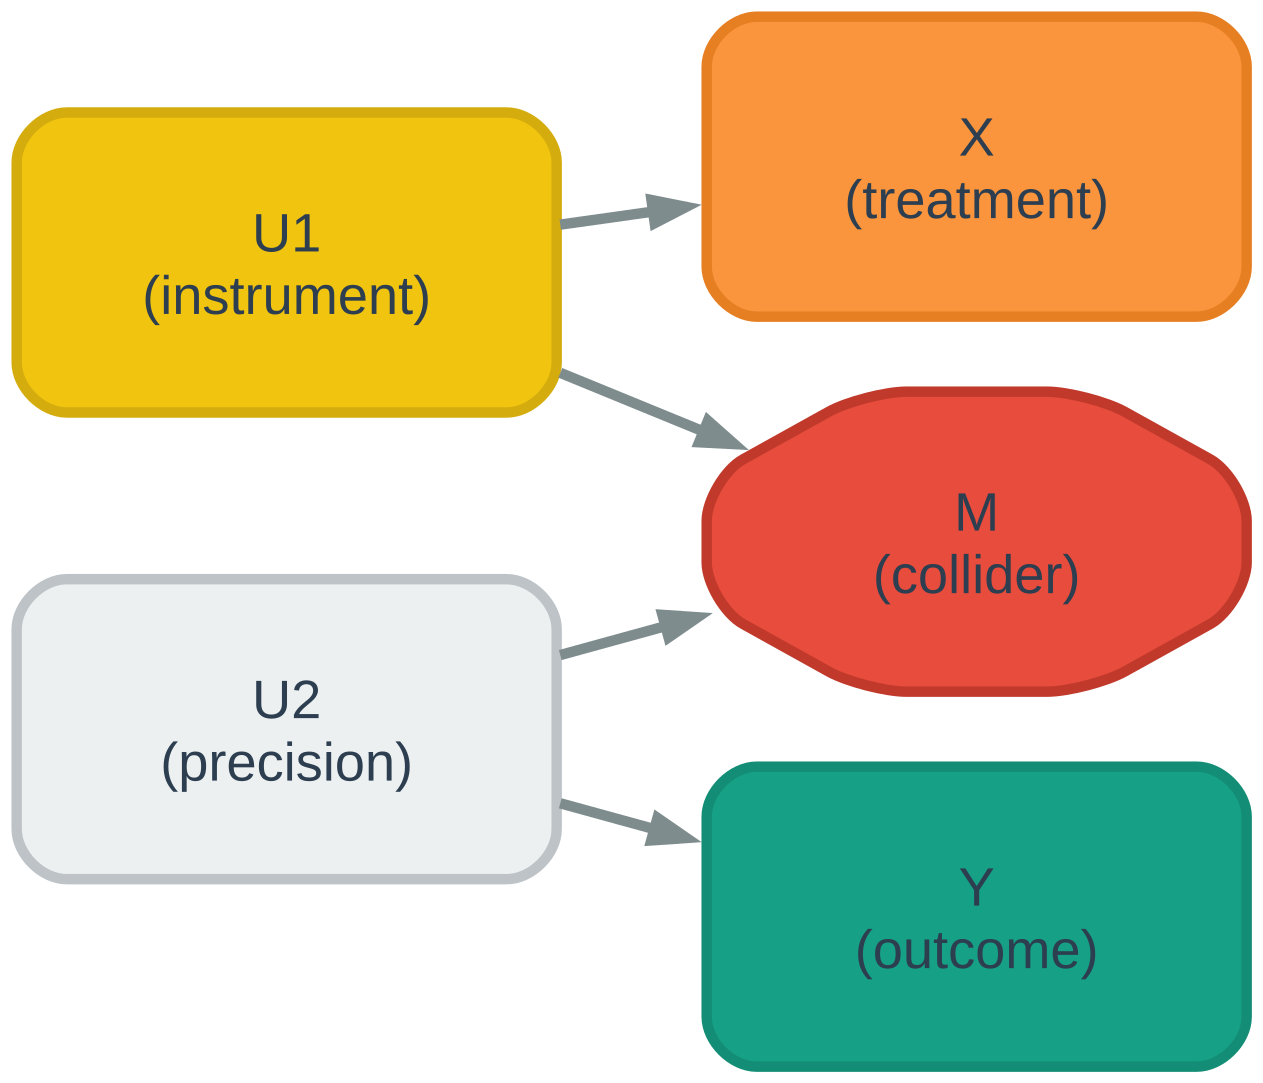

In [8]:
dag = m_bias()
dag.draw("X", "Y")

`M` is drawn as an octagon as well as in red, so the warning
survives greyscale printing and colour-blind readers.

In [9]:
print(dag.explain("X", "Y"))

Treatment: X
Outcome:   Y

NOTE: no directed path from X to Y. This graph asserts that X has no causal effect on Y; the true effect is zero by construction.

COLLIDER: M
    do NOT adjust -- conditioning on a collider creates bias that was not there
INSTRUMENT: U1
    do NOT adjust -- usable as an instrument for IV estimation
PRECISION: U2
    optional -- affects only the outcome, so it tightens estimates without changing the estimand

WHAT A BACKDOOR ADJUSTMENT GIVES YOU:
    No confounders in this graph, so no adjustment is needed for identification. That is a strong assumption -- it says nothing unobserved causes both treatment and outcome.


In [10]:
df = simulate(dag, n=N, seed=SEED)

print(f"True effect of X on Y      : {true_total_effect(dag, 'X', 'Y'):.3f}")
print(f"Naive  (Y ~ X)             : {ols(df, 'X', 'Y'):+.3f}   <- correct!")
print(f"Adjusted (Y ~ X + M)       : {ols(df, 'X', 'Y', ['M']):+.3f}   <- invented from nothing")

True effect of X on Y      : 0.000
Naive  (Y ~ X)             : -0.006   <- correct!
Adjusted (Y ~ X + M)       : -0.201   <- invented from nothing


Read those last two lines again.

The **naive** regression gets it right. Adding a control variable produces an
effect where the truth is exactly zero.

### Why

`M` is a collider on the path `X ← U1 → M ← U2 → Y`. That path is **blocked by
default** — colliders block the paths they sit on, so `X` and `Y` are
unassociated, which is what the naive regression correctly reports.

Conditioning on a collider **opens** it. Once you hold `M` fixed, learning `U1`
tells you about `U2`: if `M` is high and `U1` was low, `U2` must have been high.
That manufactured association between `U1` and `U2` propagates into a spurious
association between `X` and `Y`.

The everyday version: suppose talent and looks are independent, but either one
gets you into Hollywood. Among *actors*, the two are negatively correlated — a
talentless actor who made it probably got there on looks. The correlation is
entirely an artefact of looking only at people who got in. Conditioning on the
collider created it. This is why it is also called **selection bias** or
**Berkson's paradox**.

You cannot detect this from the data. Nothing in the fit output is unusual. R²
improves. The only way to know is to have written down the graph.

---
## The scoreboard

In [11]:
rows = []
for label, dag, control in [
    ("Confounder", confounded(), "Z"),
    ("Mediator",   mediated(),   "M"),
    ("Collider",   m_bias(),     "M"),
]:
    df = simulate(dag, n=N, seed=SEED)
    rows.append({
        "Structure":        label,
        "True total effect": true_total_effect(dag, "X", "Y"),
        "Y ~ X":            ols(df, "X", "Y"),
        f"Y ~ X + control": ols(df, "X", "Y", [control]),
    })

summary = pd.DataFrame(rows).set_index("Structure")
summary["Adjusting helps?"] = ["yes", "changes the question", "NO - creates bias"]
summary

,True total effect,Y ~ X,Y ~ X + control,Adjusting helps?
Structure,,,,
Confounder,1.5,2.504,1.505,yes
Mediator,2.0,1.993,1.000,changes the question
Collider,0.0,-0.006,-0.201,NO - creates bias


Same statistical operation — add a variable to a regression —
with three different consequences. The data cannot tell you which situation you
are in, because all three produce correlations that look alike.

## So what *is* the rule?

Not "adjust for everything." Not "adjust for nothing." The rule is:

> Adjust for a set of variables that blocks every **backdoor path** from
> treatment to outcome, without opening any new ones.

A backdoor path is a non-causal route connecting treatment and outcome, running
against an arrow somewhere — the mechanism by which correlation appears without
causation. This is Pearl's **backdoor criterion**, and it is a statement about
the *graph*, not about the data. Which is why the graph has to come first.

That is the part my degree left out. We were taught estimation in real depth —
regularisation, cross-validation, standard errors — and nothing at all about
identification: the prior question of whether the quantity you want is
recoverable from the data you have, under assumptions you are willing to state.
No amount of estimation skill substitutes. You can fit a flawless model to a
quantity that is not the one you meant.

---

## One more thing

Everything above used graphs I designed to make a point. Here is one from a real
analysis — [`01_small_towns.ipynb`](01_small_towns.ipynb), on whether small
English towns produce better educational outcomes.

I built this DAG by hand and hand-coloured `income_flag` as a *confounder*: the
tool at the time let me pass a colour with each node, and I picked the one I
believed.

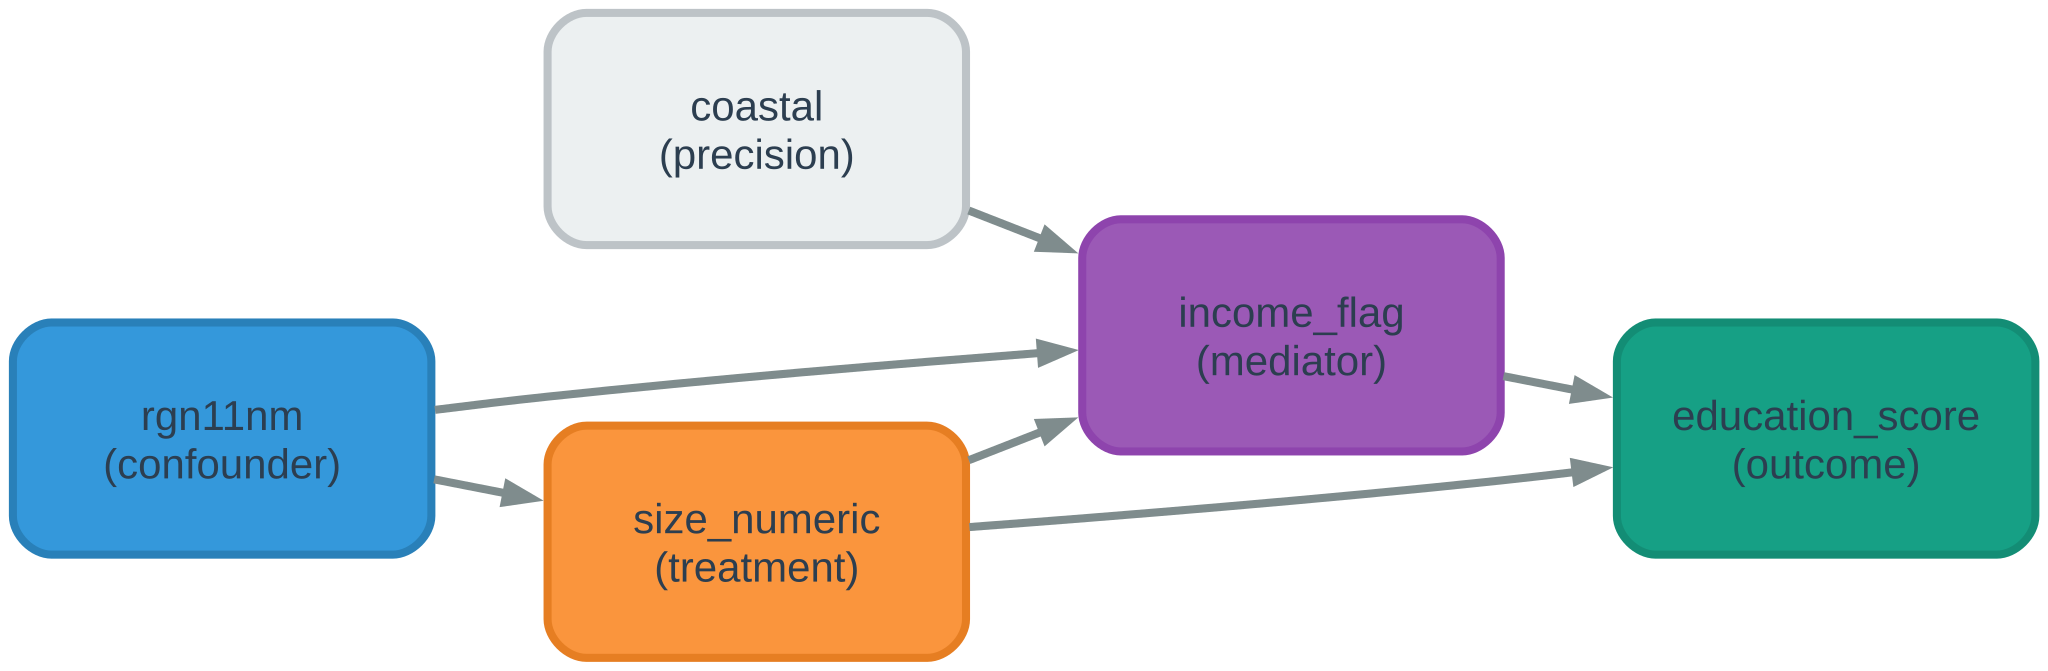

In [12]:
education = (
    CausalDAG()
    .add("coastal",        to=["income_flag"])
    .add("rgn11nm",        to=["income_flag", "size_numeric"])
    .add("size_numeric",   to=["income_flag", "education_score"])
    .add("income_flag",    to=["education_score"])
    .add("education_score")
)
education.draw("size_numeric", "education_score")

In [13]:
print(education.explain("size_numeric", "education_score"))

Treatment: size_numeric
Outcome:   education_score

MEDIATOR: income_flag
    adjusting for it gives the DIRECT effect, not the total effect
CONFOUNDER: rgn11nm
    adjust for it -- it is a common cause and leaves an open backdoor path
PRECISION: coastal
    optional -- affects only the outcome, so it tightens estimates without changing the estimand

WHAT A BACKDOOR ADJUSTMENT GIVES YOU:
    Adjusting for {rgn11nm} -> TOTAL effect (through every pathway).
    Adding the mediator(s) {income_flag} -> DIRECT effect only.
    These answer different questions. Say which one you report.


`income_flag` is a **mediator**, not a confounder. I had wired
it as `size → income → education` and then labelled it as a common cause. The
arrows I drew and the word I wrote disagreed, and because the colour was
something I *asserted* rather than something the graph *computed*, nothing
caught it.

That is the whole reason roles are derived here instead of declared. The class
of error is not "I made a mistake" — it is "the tool let the picture and the
analysis say different things." Compute one from the other and the disagreement
becomes impossible.

It also changes what the analysis means. Because income is a mediator, adjusting
for it yields the *direct* effect of town size, not the total. That distinction
turns out to be the entire finding — see the next notebook.